# Image and Video Processing Lab 3

### Importing Libraries

In [1]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.5 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure, metrics
import torch
import lpips

## Task I: Histogram Creation

### Loading Image

In [3]:
def plot_img_and_hist(image, title, bins=256, range_val=[0, 256]):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Image
    axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title(f'{title} Image')
    axes[0].axis('off')

    # Plot Histogram
    axes[1].hist(image.ravel(), bins=bins, range=range_val)
    axes[1].set_title(f'{title} Histogram')
    axes[1].set_xlabel('Intensity')
    axes[1].set_ylabel('Pixel Count')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [4]:
img = cv2.imread('doggy.jpg', cv2.IMREAD_GRAYSCALE)

Experiment 1: Plotting Original Histogram


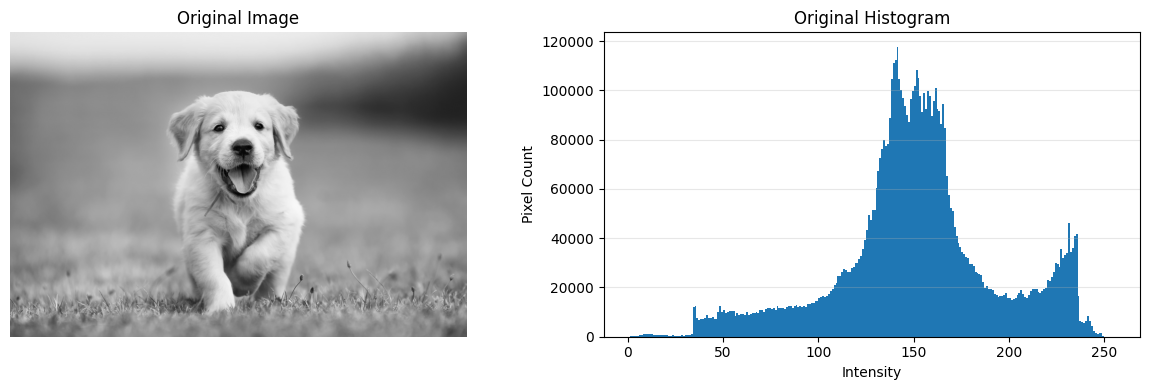

In [5]:
print("Experiment 1: Plotting Original Histogram")
plot_img_and_hist(img, "Original")

## Task II: Histogram Equalization

Experiment 2: Histogram Equalization


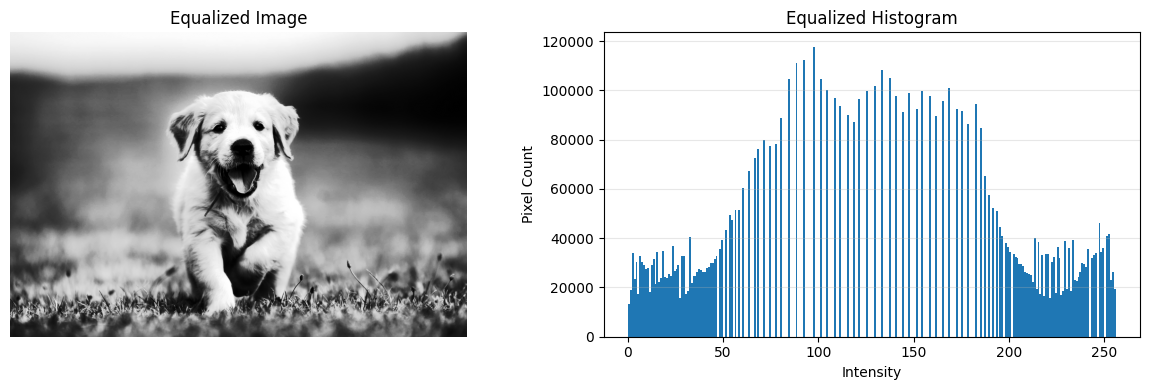

In [6]:
print("Experiment 2: Histogram Equalization")
img_eq = cv2.equalizeHist(img)
plot_img_and_hist(img_eq, "Equalized")

## Task III: Histogram Modification

In [7]:
print("Experiment 3: Histogram Modification (Matching)")
# We create a dummy reference image (a darker, lower contrast image)
np.random.seed(42)
ref_img = np.random.normal(60, 15, img.shape).astype(np.uint8)

Experiment 3: Histogram Modification (Matching)


In [8]:
matched_img = exposure.match_histograms(img, ref_img)

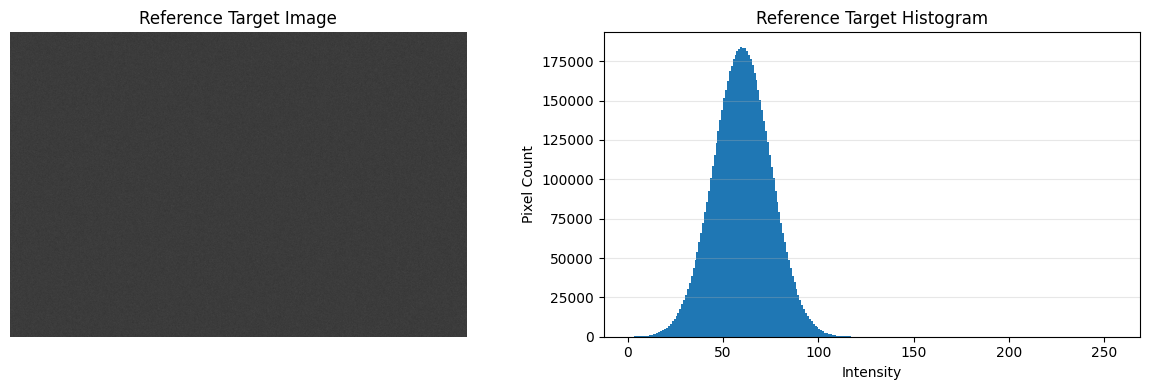

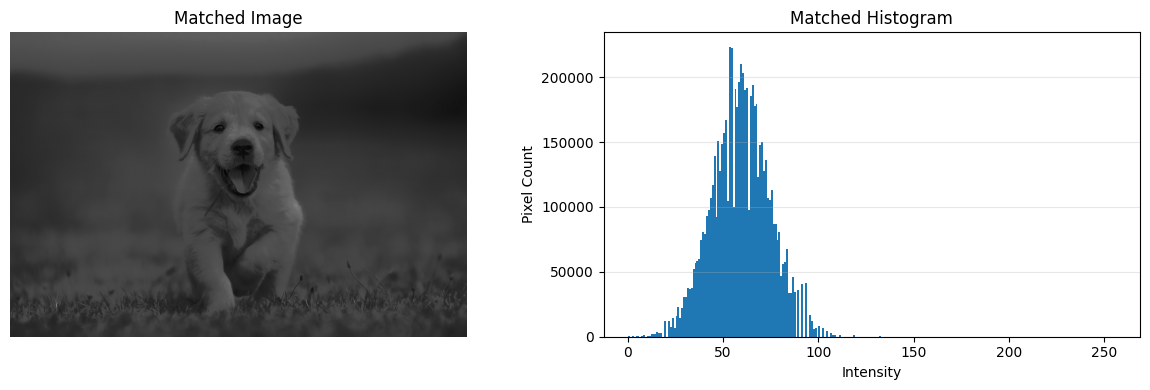

In [9]:
matched_img = np.clip(matched_img, 0, 255).astype(np.uint8)

plot_img_and_hist(ref_img, "Reference Target")
plot_img_and_hist(matched_img, "Matched")

## Task IV: Reflection of a Line (Negative)

Experiment 4: Transform Image (Reflection of a line y = x)


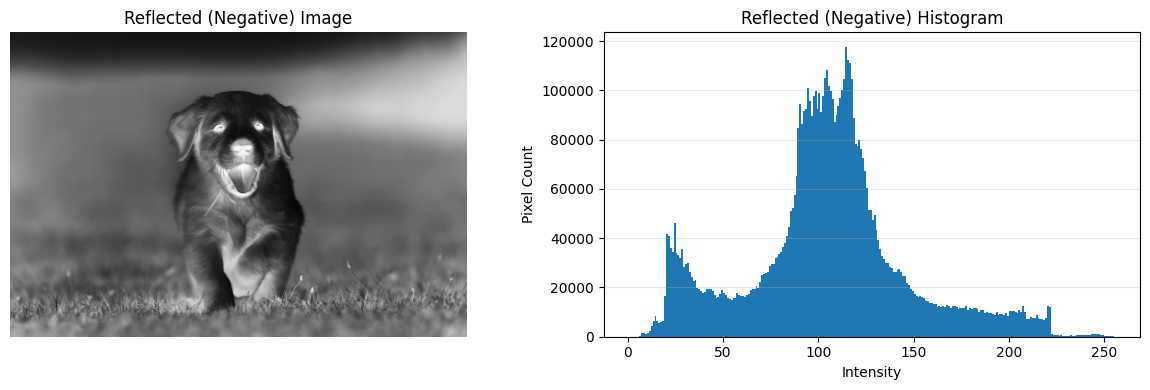

In [10]:
print("Experiment 4: Transform Image (Reflection of a line y = x)")

img_reflected = 255 - img
plot_img_and_hist(img_reflected, "Reflected (Negative)")

## Task V: 3-Bit Image with Specific PDF

Experiment 5: Generate 3-bit image satisfying y = -2x + 2


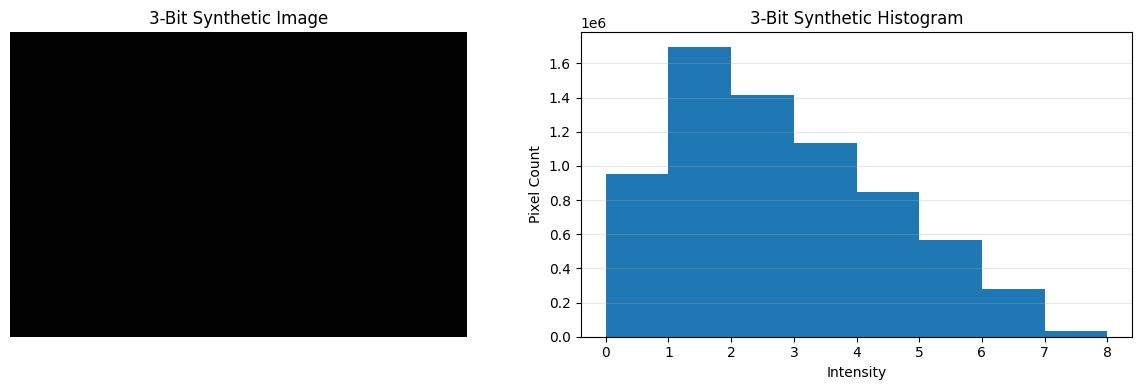

In [11]:
print("Experiment 5: Generate 3-bit image satisfying y = -2x + 2")

# 1. Generate a uniform random array (u) bounded between 0 and 1
u = np.random.uniform(0, 1, img.shape)

# 2. Apply the inverse CDF derived from the PDF y = -2x + 2
# The CDF is F(x) = -x^2 + 2x. Setting u = -x^2 + 2x and solving for x gives:
x = 1 - np.sqrt(1 - u)

# 3. Scale the [0, 1] distribution to 3-bit discrete levels (0 to 7)
img_3bit = np.uint8(np.round(x * 7))

# Plot the 3-bit image. Notice the bins and range are restricted to 0-8!
plot_img_and_hist(img_3bit, "3-Bit Synthetic", bins=8, range_val=[0, 8])

## Task VI: PSNR, SSIM, LPIPS

### Calculating Metrics

In [12]:
print("Experiment 6: Image Metrics")

# 1. PSNR (Peak Signal-to-Noise Ratio)
psnr_val = cv2.PSNR(img, img_eq)

# 2. SSIM (Structural Similarity Index)
ssim_val, _ = metrics.structural_similarity(img, img_eq, full=True)

# 3. LPIPS (Learned Perceptual Image Patch Similarity)
# LPIPS expects tensors in range [-1, 1] with shape (N, C, H, W)
loss_fn_alex = lpips.LPIPS(net='alex') # Initialize the model

# Convert images to tensors, add channel/batch dims, and normalize to [-1, 1]
img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 127.5 - 1
img_eq_tensor = torch.from_numpy(img_eq).float().unsqueeze(0).unsqueeze(0) / 127.5 - 1

lpips_val = loss_fn_alex(img_tensor, img_eq_tensor).item()

print(f"PSNR:  {psnr_val:.2f} dB")
print(f"SSIM:  {ssim_val:.4f}")
print(f"LPIPS: {lpips_val:.4f} (Lower means more perceptually similar)")

Experiment 6: Image Metrics
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 164MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
PSNR:  15.58 dB
SSIM:  0.8087
LPIPS: 0.2851 (Lower means more perceptually similar)
